# Classical baseline verification

Visual sanity-check of the brute-force Max-Cut solver on graphs with 6, 9, and 12 nodes. Confirms that highlighted (cut) edges correctly connect nodes from different groups, matching the optimal partitions saved in `fixtures/`.

In [2]:
# Imports
import sys
sys.path.append('../src')

import json
import matplotlib.pyplot as plt
import networkx as nx
from max_cut import generate_graph, solve_exact

In [3]:
# Load existing fixtures
results = {}
for n in [6, 9, 12]:
    with open(f'../fixtures/graph_{n}.json') as f:
        results[n] = json.load(f)
    print(f"n={n}: optimal cut = {results[n]['optimal_cut_value']}")

n=6: optimal cut = 7
n=9: optimal cut = 14
n=12: optimal cut = 16


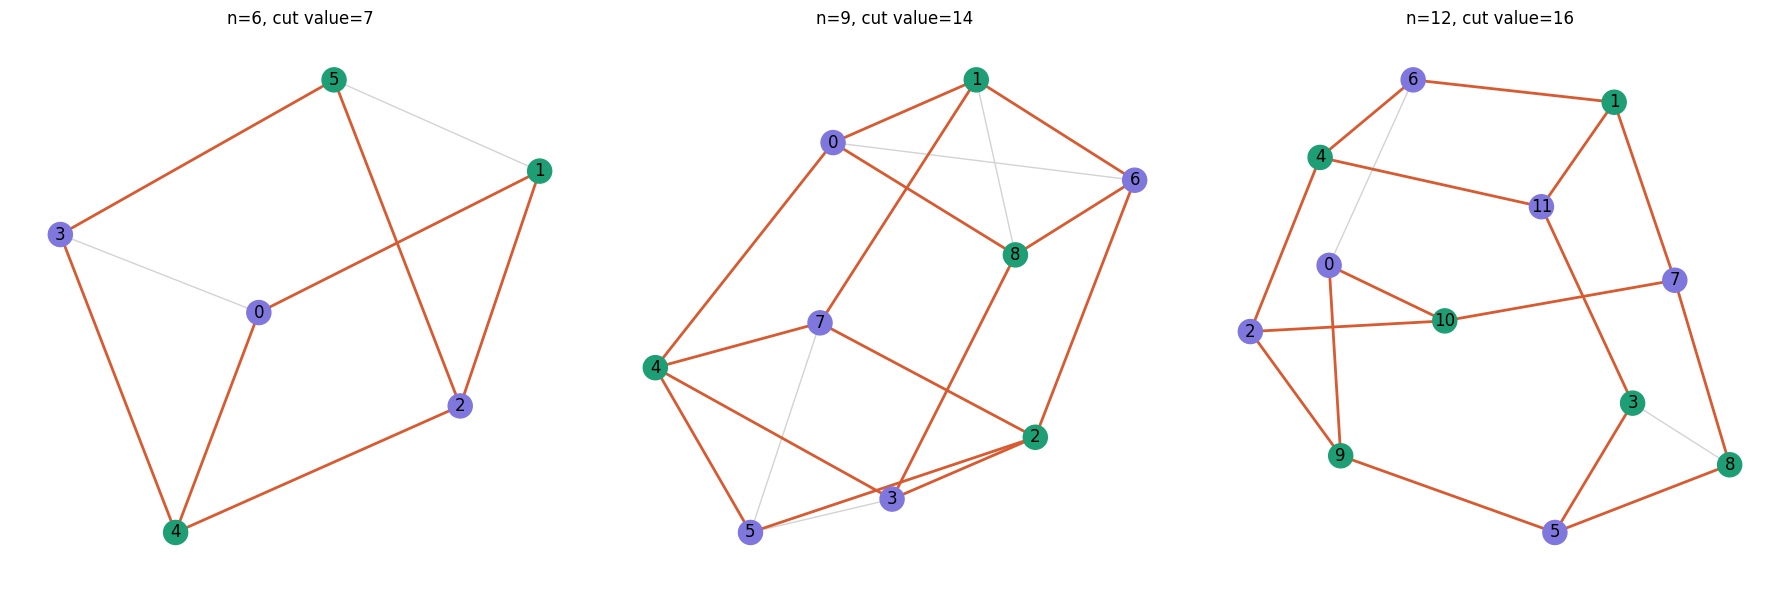

In [4]:
# Draw each graph with highlighted cut
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, n in zip(axes, [6, 9, 12]):
    data = results[n]
    graph = nx.Graph()
    graph.add_edges_from(data['edges'])
    partition = data['optimal_partition']

    pos = nx.spring_layout(graph, seed=42)
    node_colors = ['#7F77DD' if partition[node] == 0 else '#1D9E75' for node in graph.nodes()]

    cut_edges = [(i, j) for (i, j) in graph.edges() if partition[i] != partition[j]]
    uncut_edges = [(i, j) for (i, j) in graph.edges() if partition[i] == partition[j]]

    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, ax=ax)
    nx.draw_networkx_labels(graph, pos, ax=ax)
    nx.draw_networkx_edges(graph, pos, edgelist=uncut_edges, edge_color='lightgray', ax=ax)
    nx.draw_networkx_edges(graph, pos, edgelist=cut_edges, edge_color='#D85A30', width=2, ax=ax)

    ax.set_title(f"n={n}, cut value={data['optimal_cut_value']}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('../fixtures/max_cut_visual_check.png', dpi=100)
plt.show()